# 📈 Regressão Linear — Confiança × Qualidade das Anotações (LLMs)

Eixo 2 da pesquisa. Enquanto o **projeto fatorial** opera no nível dos
tratamentos, a **regressão opera no nível individual de cada anotação**: cada
linha é **um exemplo anotado** pelo consenso entre os 3 modelos
(**Llama3.1-8B**, **Qwen3-8B**, **DeepSeek-R1-8B**).

**Objetivo:** investigar se as medidas de confiança dos LLMs são indicadores da
qualidade (acerto) das anotações geradas automaticamente.

**Datasets** (uma pasta por dataset):

| Dataset | Domínio | Pasta usada |
|---------|---------|-------------|
| AGNews      | notícias  | última pasta |
| MovieReview | reviews   | 1ª replicação (após "3 modelos") |
| DBLP        | técnico   | última pasta |
| Books       | técnico   | 1ª replicação (após "3 modelos") |

O consenso é construído **reutilizando `ConsensusCalculator` /
`ConsensusEvaluator`** (mesma máquina dos outros notebooks). Aqui o
`consensus_type` é o **padrão de concordância** de cada exemplo (uma partição,
1 linha por exemplo):

- **3×0** = os 3 modelos concordam (unânime);
- **2×1** = exatamente 2 concordam (maioria simples, 1 discorda).

Logo, `nº(2×1) + nº(3×0) = total de exemplos com maioria`.

> Variável-resposta `correct` é binária ⇒ usamos **Modelo de Probabilidade Linear
> (LPM)** por foco metodológico/interpretabilidade, reportando **erros-padrão
> robustos (HC1)** por causa da heterocedasticidade inerente.


## 1) Setup e configuração

In [1]:
import os
import sys
import glob
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.nonparametric.smoothers_lowess import lowess

from loguru import logger

ROOT = Path.cwd()
while not (ROOT / "data" / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.llm_annotation_system.consensus.consensus_calculator import ConsensusCalculator
from src.llm_annotation_system.consensus.consensus_evaluator import ConsensusEvaluator

logger.remove()
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

MODELS = ["llama3.1-8b", "qwen3-8b", "deepseek-r1-8b"]
CONF_COL = {m: f"{m}_rep1_conf" for m in MODELS}
CONS_COL = [f"{m}_consensus" for m in MODELS]
SHORT = {"llama3.1-8b": "llama", "qwen3-8b": "qwen", "deepseek-r1-8b": "deepseek"}

DATASETS = ["agnews", "movie_review", "dblp", "books"]
INVALID = -1
RESULTS_DIR = ROOT / "data" / "results"

# Amostra para gráficos/diagnósticos pesados (LOESS, QQ, scatter, Shapiro)
RNG = np.random.default_rng(0)
SAMPLE_N = 8000

print("Raiz do projeto:", ROOT)

Raiz do projeto: C:\Users\gabri\Documents\GitHub\llm-annotation


## 2) Seleção das pastas e construção da base

- **AGNews / DBLP**: última pasta com `annotations.csv`.
- **MovieReview / Books**: 1ª replicação (primeira pasta com nome de timestamp
  `YYYY-MM-DD_HH-MM-SS`, ou seja, logo após a pasta "3 modelos").

**Uma linha por exemplo.** Calculamos o consenso (estratégia `majority_vote`) e
classificamos cada exemplo pelo **padrão de concordância** dos 3 modelos:

- **3×0** (unânime) ⇔ `most_common_count == 3`;
- **2×1** (maioria simples) ⇔ `most_common_count == 2`.

Aplicamos **a mesma limpeza dos outros notebooks** (descarta `ground_truth`
inválido, `resolved_annotation == -1`) e **exigimos maioria** — exemplos com as 3
predições distintas (`most_common_count == 1`, sem maioria) são descartados.
Também removemos anotações com confiança `NaN`. Assim `2×1` e `3×0` formam uma
**partição**: `nº(2×1) + nº(3×0) = total`.

In [2]:
TS = re.compile(r"^\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}")


def folder_for(dataset):
    folders = sorted(
        d for d in glob.glob(str(RESULTS_DIR / dataset / "*") + os.sep)
        if os.path.exists(os.path.join(d, "annotations.csv"))
    )
    if dataset in ("movie_review", "books"):
        ts = [d for d in folders if TS.match(os.path.basename(d.rstrip(os.sep)))]
        return ts[0]
    return folders[-1]


def get_categories(df):
    return sorted(int(v) for v in df["ground_truth"].unique() if v != INVALID)


def build_dataset_rows(dataset):
    """Uma linha por exemplo. consensus_type = padrão de concordância dos 3 modelos:
       3x0 (unânime, most_common_count==3) ou 2x1 (maioria simples, ==2).
       Exemplos sem maioria (3 predições distintas) ou inválidos são descartados."""
    folder = folder_for(dataset)
    df = pd.read_csv(os.path.join(folder, "annotations.csv"))
    cats = get_categories(df)
    keep = ["text_id", "ground_truth"] + CONS_COL + list(CONF_COL.values())

    calc = ConsensusCalculator(consensus_threshold=0.8, default_strategy="majority_vote")
    ev = ConsensusEvaluator(categories=cats, calculator=calc, output_dir=folder)
    dfc = ev.compute_consensus(df[keep].copy())

    # limpeza (igual ao pré-consenso) + exige maioria (descarta 3 predições distintas)
    dfc = dfc[(dfc["ground_truth"] != INVALID)
              & (dfc["resolved_annotation"] != INVALID)
              & (dfc["most_common_count"] >= 2)]

    r = pd.DataFrame({
        "dataset": dataset,
        # most_common_count: 3 -> unânime (3x0) ; 2 -> maioria simples (2x1)
        "consensus_type": np.where(dfc["most_common_count"] == 3, "3x0", "2x1"),
        "ground_truth": dfc["ground_truth"].astype(int).values,
        "consensus_prediction": dfc["resolved_annotation"].astype(int).values,
        "conf_llama":    dfc[CONF_COL["llama3.1-8b"]].values,
        "conf_qwen":     dfc[CONF_COL["qwen3-8b"]].values,
        "conf_deepseek": dfc[CONF_COL["deepseek-r1-8b"]].values,
    })
    # descarta anotações com confiança não-parseada (NaN) em algum modelo
    r = r.dropna(subset=["conf_llama", "conf_qwen", "conf_deepseek"])
    return r, os.path.basename(folder.rstrip(os.sep))


frames, used = [], {}
for ds in DATASETS:
    fr, fold = build_dataset_rows(ds)
    frames.append(fr)
    used[ds] = fold
    n2 = int((fr["consensus_type"] == "2x1").sum())
    n3 = int((fr["consensus_type"] == "3x0").sum())
    print(f"{ds:13s} <- {fold:30s} | 2x1={n2:6d} + 3x0={n3:6d} = {len(fr)}")

df_reg = pd.concat(frames, ignore_index=True)
print("\nTotal de anotações (1 por exemplo):", len(df_reg))

agnews        <- 2026-04-09_13-20-16 - rep1     | 2x1= 11758 + 3x0=115551 = 127309
movie_review  <- 2026-04-09_13-17-23            | 2x1=  1043 + 3x0=  9577 = 10620


dblp          <- 2026-04-09_14-05-21            | 2x1= 10175 + 3x0= 27060 = 37235


books         <- 2026-04-09_13-21-37            | 2x1=  8181 + 3x0= 24810 = 32991

Total de anotações (1 por exemplo): 208155


## Passo 1 e 2 — Variável-resposta e variáveis explicativas

- `correct` = 1 se `consensus_prediction == ground_truth`, senão 0.
- `mean_confidence` = média das 3 confianças; `std_confidence` = desvio (dispersão
  entre os modelos, ddof=0).
- `consensus_code` = 0 (2×1) / 1 (3×0); `dataset` categórico.

In [3]:
conf_cols = ["conf_llama", "conf_qwen", "conf_deepseek"]

df_reg["correct"] = (df_reg["consensus_prediction"] == df_reg["ground_truth"]).astype(int)
df_reg["mean_confidence"] = df_reg[conf_cols].mean(axis=1)
df_reg["std_confidence"] = df_reg[conf_cols].std(axis=1, ddof=0)
df_reg["consensus_code"] = df_reg["consensus_type"].map({"2x1": 0, "3x0": 1})

df_reg.head()

,dataset,consensus_type,ground_truth,consensus_prediction,conf_llama,conf_qwen,conf_deepseek,correct,mean_confidence,std_confidence,consensus_code
0,agnews,3x0,1,1,1.0000,1.0000,0.9974,1,0.9991,0.0012,1
1,agnews,3x0,2,2,0.9962,1.0000,0.9983,1,0.9982,0.0016,1
2,agnews,3x0,1,1,1.0000,1.0000,0.9960,1,0.9987,0.0019,1
3,agnews,3x0,2,2,1.0000,1.0000,0.9995,1,0.9998,0.0002,1
4,agnews,3x0,3,3,0.9992,1.0000,0.9977,1,0.9990,0.0009,1


In [4]:
print("Resumo da base:")
print(df_reg[["dataset", "consensus_type"]].value_counts().sort_index())
print("\nTipos:")
print(df_reg.dtypes)

Resumo da base:
dataset       consensus_type
agnews        2x1                11758
              3x0               115551
books         2x1                 8181
              3x0                24810
dblp          2x1                10175
              3x0                27060
movie_review  2x1                 1043
              3x0                 9577
Name: count, dtype: int64

Tipos:
dataset                  object
consensus_type           object
ground_truth              int64
consensus_prediction      int64
conf_llama              float64
conf_qwen               float64
conf_deepseek           float64
correct                   int64
mean_confidence         float64
std_confidence          float64
consensus_code            int64
dtype: object


## Passo 3 — Análise exploratória

### 3.1) Variável-resposta `correct`

,frequencia,proporcao
correct,,
acerto,168079,0.8075
erro,40076,0.1925


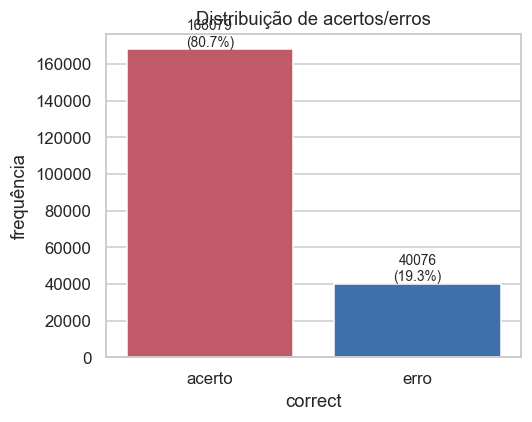

In [5]:
freq = df_reg["correct"].value_counts().rename({0: "erro", 1: "acerto"})
prop = df_reg["correct"].value_counts(normalize=True).rename({0: "erro", 1: "acerto"})
tab = pd.DataFrame({"frequencia": freq, "proporcao": prop})
display(tab)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=tab.index, y=tab["frequencia"], ax=ax, palette=["#d1495b", "#2c6fbb"])
for i, v in enumerate(tab["frequencia"]):
    ax.annotate(f"{v}\n({tab['proporcao'].iloc[i]:.1%})", (i, v),
                ha="center", va="bottom", fontsize=9)
ax.set_title("Distribuição de acertos/erros")
ax.set_ylabel("frequência")
plt.tight_layout(); plt.show()

### 3.2) Distribuição das confianças

,count,mean,std,min,25%,50%,75%,max
conf_llama,208155.0000,0.9509,0.1535,0.0026,0.9955,0.9998,1.0000,1.0000
conf_qwen,208155.0000,0.9999,0.0062,0.1719,1.0000,1.0000,1.0000,1.0000
conf_deepseek,208155.0000,0.9956,0.0248,0.0800,0.9968,0.9981,0.9989,1.0000
mean_confidence,208155.0000,0.9821,0.0523,0.4174,0.9966,0.9990,0.9995,1.0000
std_confidence,208155.0000,0.0243,0.0723,0.0000,0.0007,0.0012,0.0038,0.4698


C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


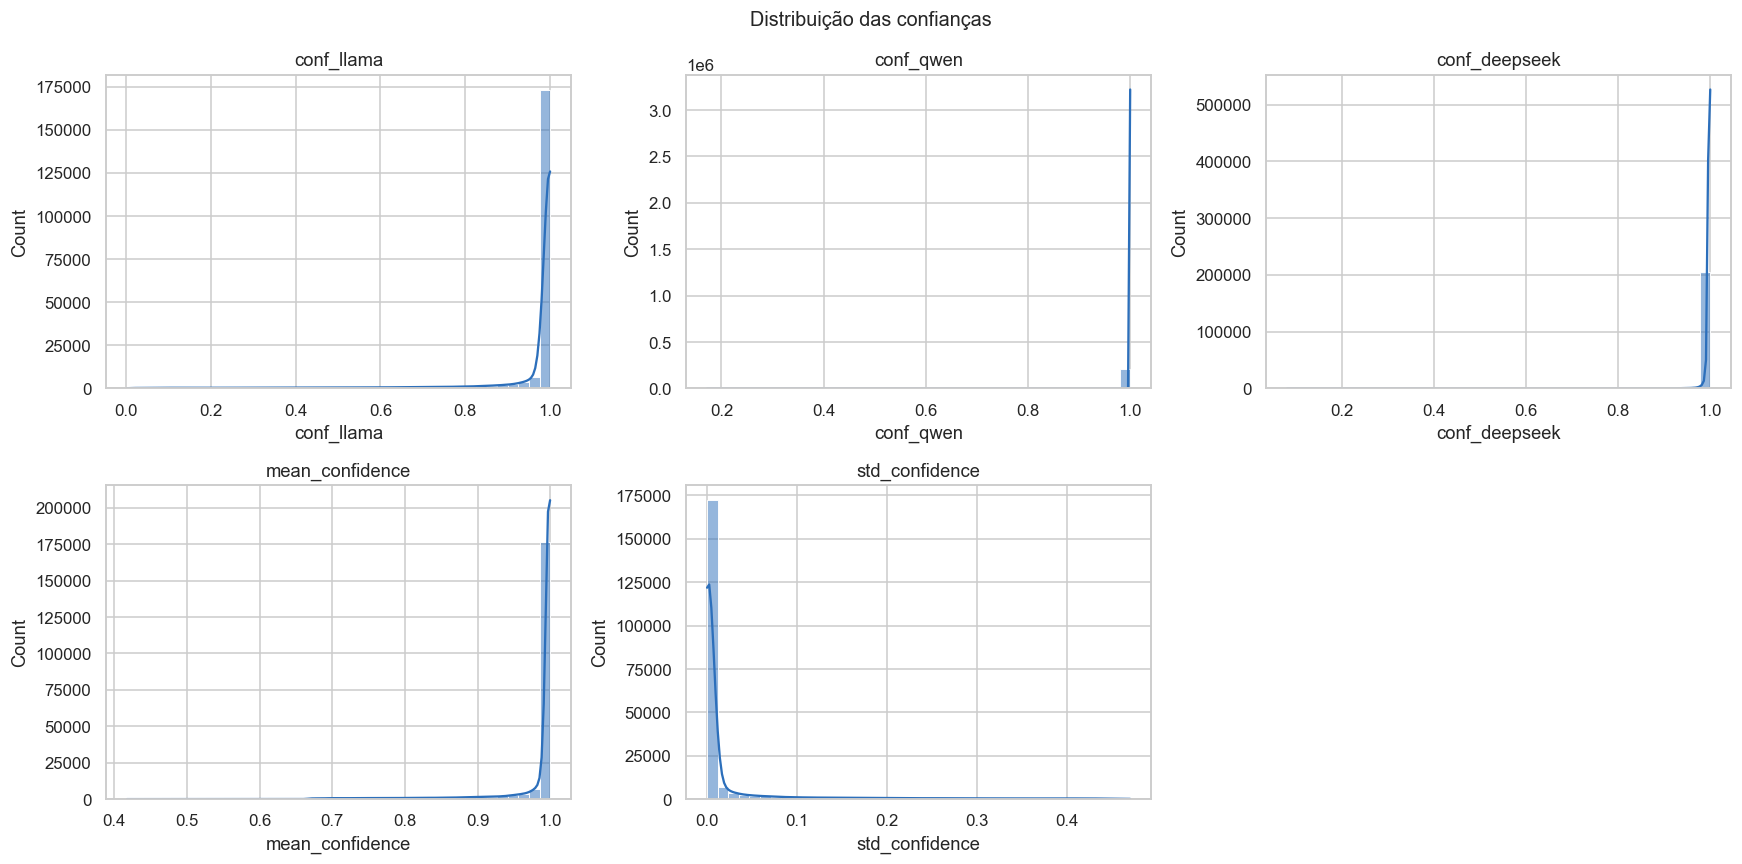

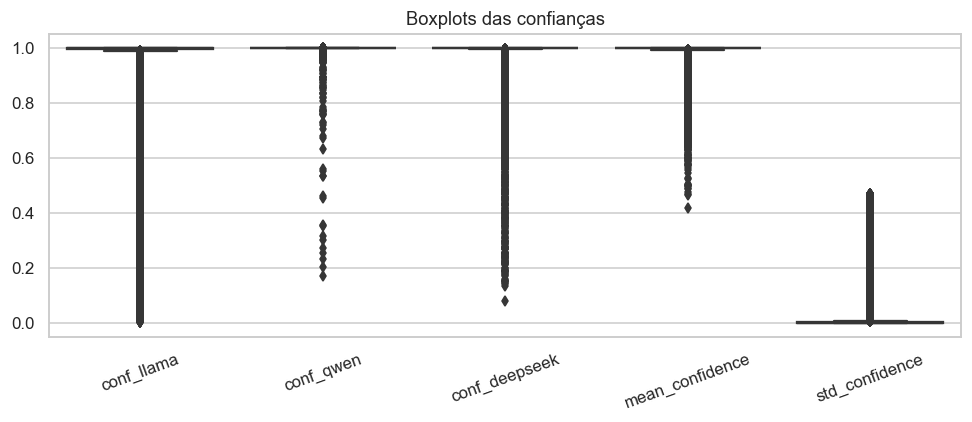

In [6]:
conf_all = conf_cols + ["mean_confidence", "std_confidence"]
display(df_reg[conf_all].describe(percentiles=[.25, .5, .75]).T)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), conf_all):
    sns.histplot(df_reg[c], bins=40, kde=True, ax=ax, color="#2c6fbb")
    ax.set_title(c)
axes.ravel()[-1].axis("off")
fig.suptitle("Distribuição das confianças", fontsize=13)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df_reg[conf_all], ax=ax, palette="Blues")
ax.set_title("Boxplots das confianças")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

### 3.3) Confiança × Acerto

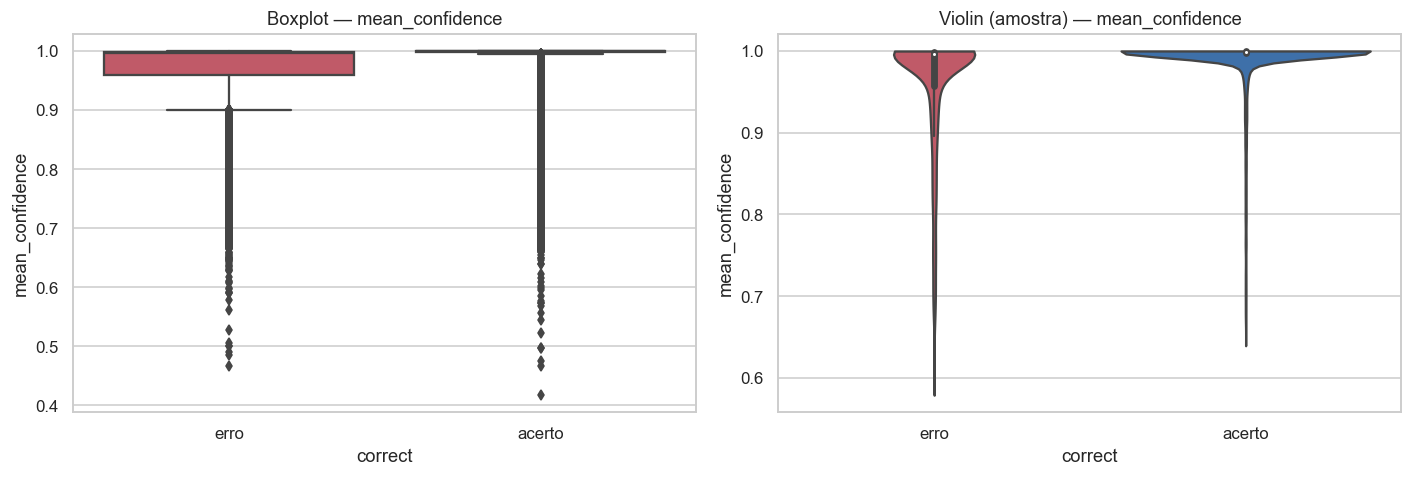

,mean,count
conf_bin,,
"(0.4, 0.5]",0.6250,8
"(0.5, 0.6]",0.4762,21
"(0.6, 0.7]",0.4453,1271
"(0.7, 0.8]",0.5077,4778
"(0.8, 0.9]",0.5372,7063
"(0.9, 1.0]",0.8270,195014


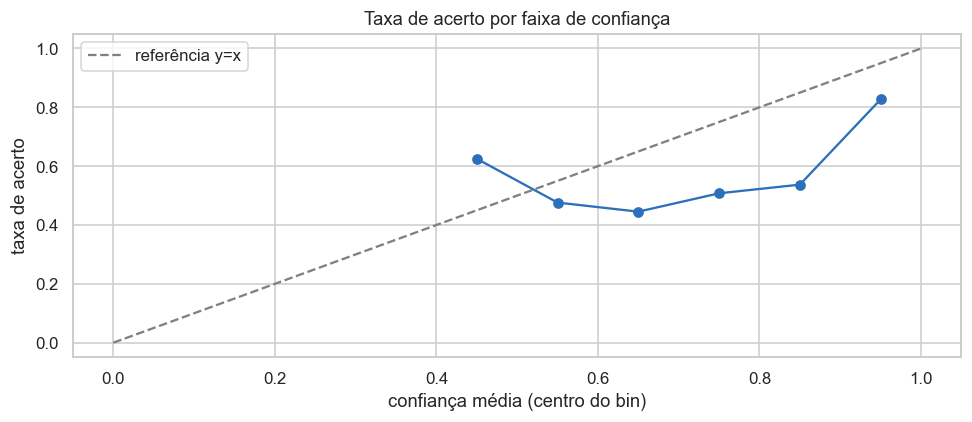

In [7]:
samp = df_reg.sample(min(SAMPLE_N, len(df_reg)), random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df_reg, x="correct", y="mean_confidence", ax=axes[0],
            palette=["#d1495b", "#2c6fbb"])
axes[0].set_xticklabels(["erro", "acerto"]); axes[0].set_title("Boxplot — mean_confidence")
sns.violinplot(data=samp, x="correct", y="mean_confidence", ax=axes[1],
               palette=["#d1495b", "#2c6fbb"], cut=0)
axes[1].set_xticklabels(["erro", "acerto"]); axes[1].set_title("Violin (amostra) — mean_confidence")
plt.tight_layout(); plt.show()

# taxa de acerto por faixa de confiança
bins = np.linspace(0, 1, 11)
df_reg["conf_bin"] = pd.cut(df_reg["mean_confidence"], bins=bins, include_lowest=True)
rate = df_reg.groupby("conf_bin", observed=True)["correct"].agg(["mean", "count"])
display(rate)

fig, ax = plt.subplots(figsize=(9, 4))
x = [iv.mid for iv in rate.index]
ax.plot(x, rate["mean"], "o-", color="#2c6fbb")
ax.plot([0, 1], [0, 1], "--", color="gray", label="referência y=x")
ax.set_xlabel("confiança média (centro do bin)"); ax.set_ylabel("taxa de acerto")
ax.set_title("Taxa de acerto por faixa de confiança"); ax.legend()
plt.tight_layout(); plt.show()
df_reg.drop(columns="conf_bin", inplace=True)

### 3.4) Distribuições por dataset e por tipo de consenso

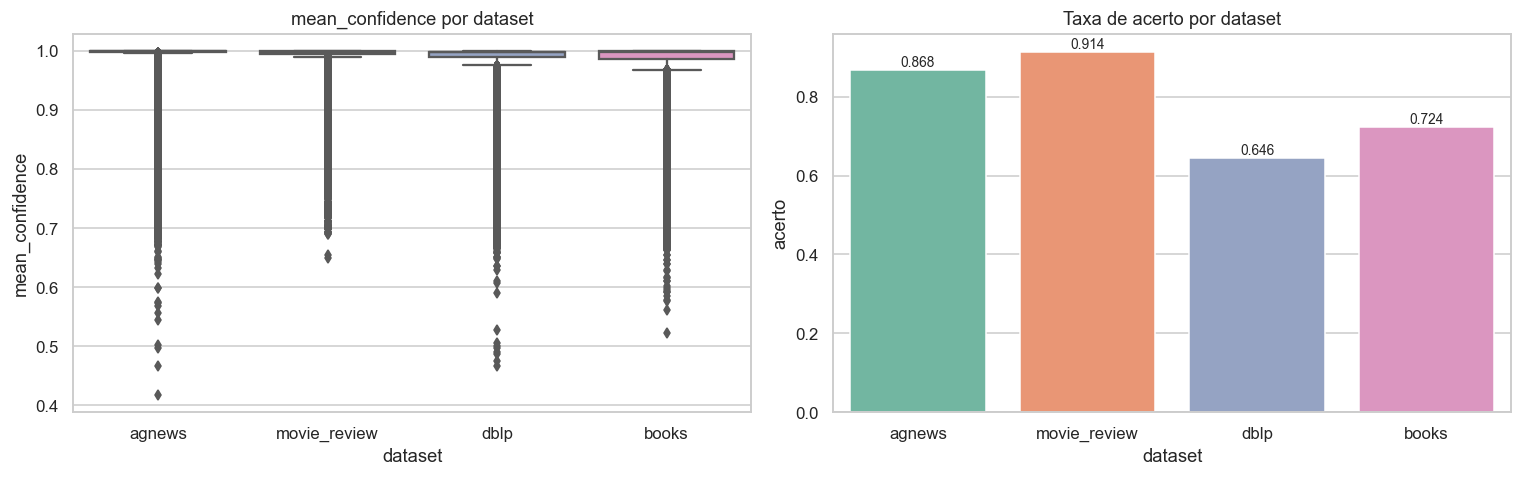

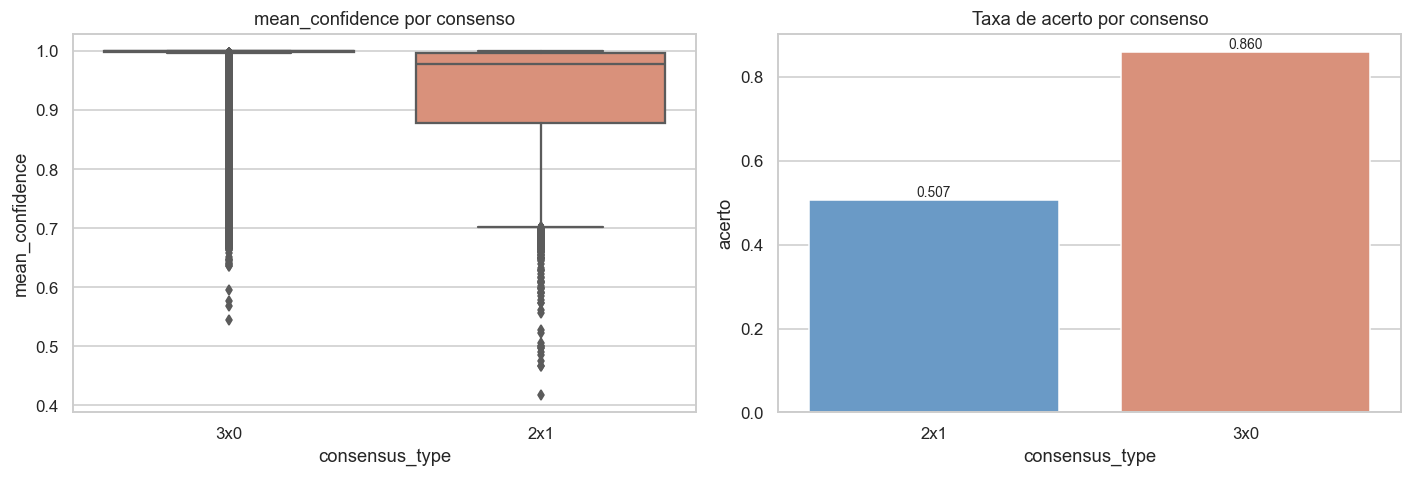

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df_reg, x="dataset", y="mean_confidence", ax=axes[0], palette="Set2")
axes[0].set_title("mean_confidence por dataset")
acc_ds = df_reg.groupby("dataset")["correct"].mean().reindex(DATASETS)
sns.barplot(x=acc_ds.index, y=acc_ds.values, ax=axes[1], palette="Set2")
for i, v in enumerate(acc_ds.values):
    axes[1].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=9)
axes[1].set_title("Taxa de acerto por dataset"); axes[1].set_ylabel("acerto")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df_reg, x="consensus_type", y="mean_confidence", ax=axes[0],
            palette=["#5b9bd5", "#e8896c"])
axes[0].set_title("mean_confidence por consenso")
acc_cs = df_reg.groupby("consensus_type")["correct"].mean()
sns.barplot(x=acc_cs.index, y=acc_cs.values, ax=axes[1], palette=["#5b9bd5", "#e8896c"])
for i, v in enumerate(acc_cs.values):
    axes[1].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=9)
axes[1].set_title("Taxa de acerto por consenso"); axes[1].set_ylabel("acerto")
plt.tight_layout(); plt.show()

## Passo 4 — Correlação e multicolinearidade

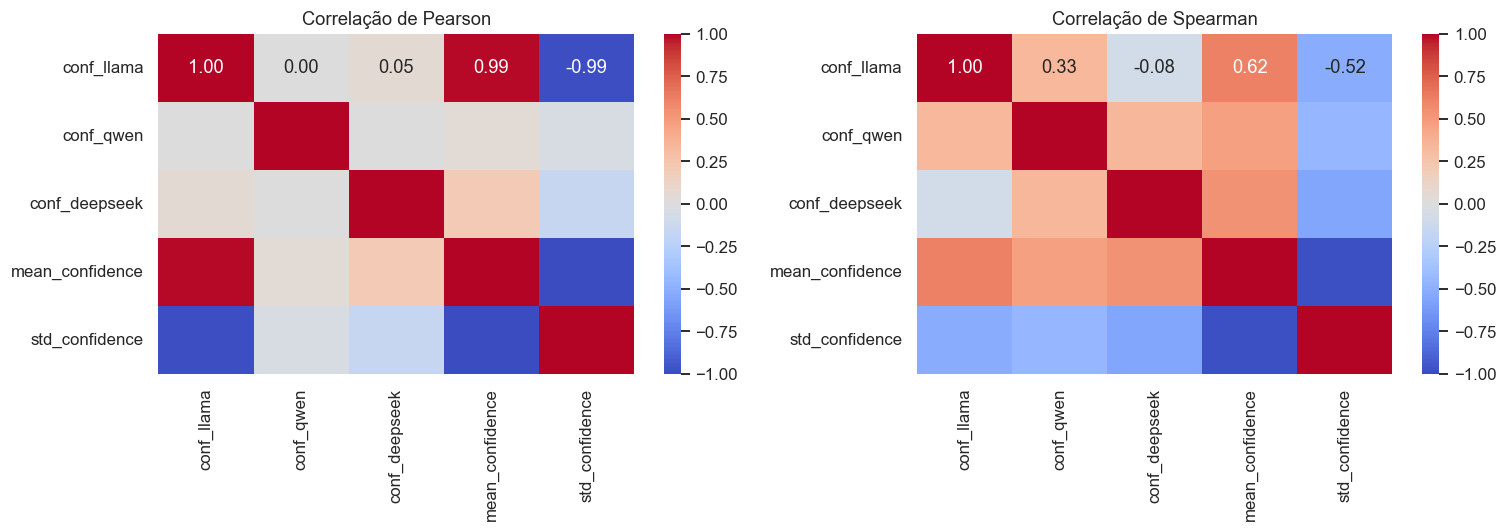

In [9]:
feat = conf_cols + ["mean_confidence", "std_confidence"]
pearson = df_reg[feat].corr(method="pearson")
spearman = df_reg[feat].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pearson, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlação de Pearson")
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlação de Spearman")
plt.tight_layout(); plt.show()

In [10]:
def compute_vif(X):
    Xc = sm.add_constant(X)
    return pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(Xc.values, i + 1) for i in range(X.shape[1])],
    })

print("VIF (inclui mean_confidence, que é combinação linear das 3 confianças):")
display(compute_vif(df_reg[feat]))
print("VIF apenas com as confianças individuais + std (sem a média redundante):")
display(compute_vif(df_reg[conf_cols + ["std_confidence"]]))

VIF (inclui mean_confidence, que é combinação linear das 3 confianças):


C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,conf_llama,inf
1,conf_qwen,inf
2,conf_deepseek,inf
3,mean_confidence,inf
4,std_confidence,198.7399


VIF apenas com as confianças individuais + std (sem a média redundante):


,feature,VIF
0,conf_llama,193.8200
1,conf_qwen,1.2341
2,conf_deepseek,3.3769
3,std_confidence,198.7399


## Passo 5 — Pressupostos (parte 1): Linearidade

Relação entre cada confiança e `correct` via dispersão + suavização **LOESS**
(em amostra, por custo computacional).

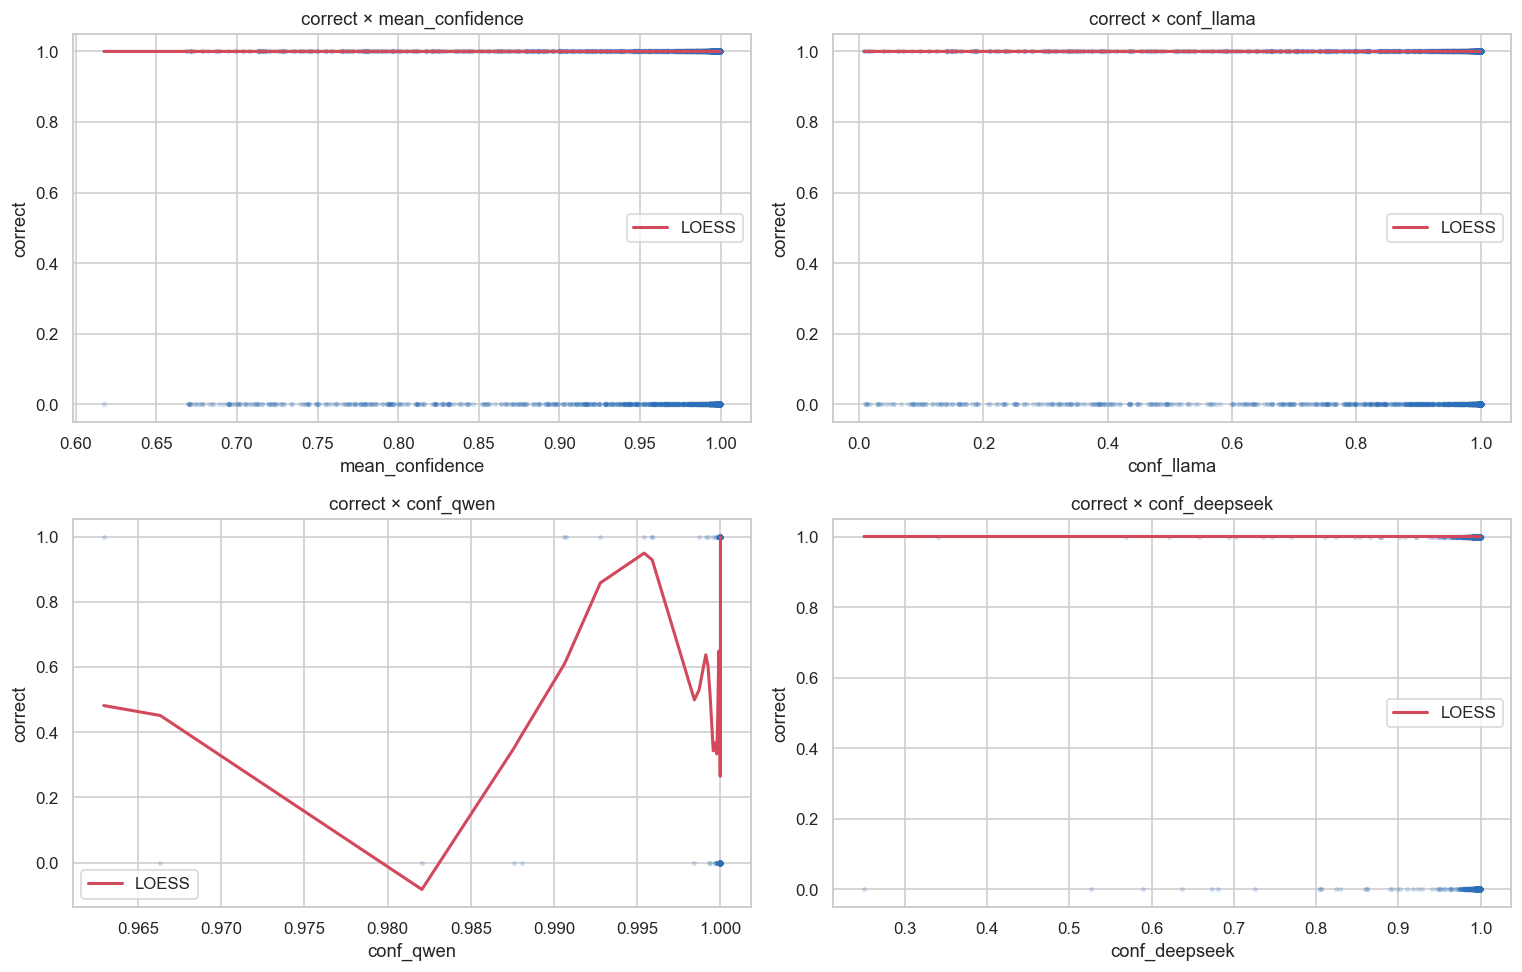

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, c in zip(axes.ravel(), ["mean_confidence"] + conf_cols):
    s = df_reg.sample(min(SAMPLE_N, len(df_reg)), random_state=1)
    ax.scatter(s[c], s["correct"], s=6, alpha=0.15, color="#2c6fbb")
    lo = lowess(s["correct"], s[c], frac=0.4, return_sorted=True)
    ax.plot(lo[:, 0], lo[:, 1], color="#d1495b", lw=2, label="LOESS")
    ax.set_xlabel(c); ax.set_ylabel("correct"); ax.set_title(f"correct × {c}"); ax.legend()
plt.tight_layout(); plt.show()

## Passo 6 — Transformações

A confiança é fortemente assimétrica (concentrada perto de 1). Para
interpretabilidade dos coeficientes criamos versões **padronizadas (z-score)** das
confianças. Como a resposta é binária (LPM), a normalidade/homocedasticidade dos
resíduos **não** se sustentam por construção — o remédio adotado é reportar
**erros-padrão robustos (HC1)** em todos os modelos (em vez de transformar a
resposta).

In [12]:
for c in conf_cols + ["mean_confidence", "std_confidence"]:
    df_reg[f"z_{c}"] = (df_reg[c] - df_reg[c].mean()) / df_reg[c].std(ddof=0)

df_reg[[f"z_{c}" for c in conf_cols] + ["z_mean_confidence", "z_std_confidence"]].describe().T

,count,mean,std,min,25%,50%,75%,max
z_conf_llama,208155.0000,0.0000,1.0000,-6.1791,0.2908,0.3190,0.3201,0.3202
z_conf_qwen,208155.0000,0.0000,1.0000,-134.3019,0.0158,0.0158,0.0158,0.0158
z_conf_deepseek,208155.0000,0.0000,1.0000,-36.9761,0.0488,0.1003,0.1335,0.1776
z_mean_confidence,208155.0000,-0.0000,1.0000,-10.7987,0.2777,0.3228,0.3314,0.3411
z_std_confidence,208155.0000,0.0000,1.0000,-0.3356,-0.3266,-0.3190,-0.2837,6.1579


## Passos 7 a 12 — Modelos de regressão (LPM, EP robusto HC1)

| # | Fórmula | Objetivo |
|---|---------|----------|
| M1 | `correct ~ mean_confidence` | confiança média prediz acerto? |
| M2 | `correct ~ conf_llama + conf_qwen + conf_deepseek` | qual modelo é mais informativo? |
| M3 | `correct ~ mean_confidence + C(consensus_type)` | impacto do consenso |
| M4 | `correct ~ mean_confidence * C(consensus_type)` | interação confiança × consenso |
| M5 | `correct ~ mean_confidence + C(consensus_type) + C(dataset)` | + domínio |
| M6 | `... conf individuais + std + consenso + dataset` | modelo completo |

In [13]:
FORMULAS = {
    "M1": "correct ~ mean_confidence",
    "M2": "correct ~ conf_llama + conf_qwen + conf_deepseek",
    "M3": "correct ~ mean_confidence + C(consensus_type)",
    "M4": "correct ~ mean_confidence * C(consensus_type)",
    "M5": "correct ~ mean_confidence + C(consensus_type) + C(dataset)",
    "M6": ("correct ~ conf_llama + conf_qwen + conf_deepseek + std_confidence "
           "+ C(consensus_type) + C(dataset)"),
}

models = {name: smf.ols(f, data=df_reg).fit(cov_type="HC1")
          for name, f in FORMULAS.items()}


def coef_table(res):
    ci = res.conf_int()
    return pd.DataFrame({
        "coef": res.params, "std_err (HC1)": res.bse,
        "t": res.tvalues, "p_value": res.pvalues,
        "IC 2.5%": ci[0], "IC 97.5%": ci[1],
    })

for name in ["M1", "M2", "M3", "M4"]:
    print(f"\n===== {name}: {FORMULAS[name]} =====")
    print(f"R² = {models[name].rsquared:.4f} | R²_adj = {models[name].rsquared_adj:.4f} "
          f"| n = {int(models[name].nobs)}")
    display(coef_table(models[name]))


===== M1: correct ~ mean_confidence =====
R² = 0.0532 | R²_adj = 0.0532 | n = 208155


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,-0.9004,0.0209,-43.1138,0.0000,-0.9413,-0.8594
mean_confidence,1.7389,0.0211,82.4957,0.0000,1.6976,1.7803



===== M2: correct ~ conf_llama + conf_qwen + conf_deepseek =====
R² = 0.0533 | R²_adj = 0.0533 | n = 208155


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,-1.1010,0.1980,-5.5612,0.0000,-1.4891,-0.7130
conf_llama,0.5746,0.0072,80.1695,0.0000,0.5606,0.5886
conf_qwen,0.6417,0.1923,3.3375,0.0008,0.2649,1.0186
conf_deepseek,0.7237,0.0492,14.7165,0.0000,0.6273,0.8201



===== M3: correct ~ mean_confidence + C(consensus_type) =====
R² = 0.1117 | R²_adj = 0.1117 | n = 208155


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,-0.2517,0.0225,-11.1884,0.0000,-0.2957,-0.2076
C(consensus_type)[T.3x0],0.2993,0.0034,88.5212,0.0000,0.2927,0.3060
mean_confidence,0.8192,0.0240,34.0888,0.0000,0.7721,0.8663



===== M4: correct ~ mean_confidence * C(consensus_type) =====
R² = 0.1222 | R²_adj = 0.1222 | n = 208155


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,0.3669,0.0275,13.3215,0.0000,0.3129,0.4209
C(consensus_type)[T.3x0],-1.4392,0.0472,-30.4774,0.0000,-1.5318,-1.3466
mean_confidence,0.1513,0.0296,5.1130,0.0000,0.0933,0.2092
mean_confidence:C(consensus_type)[T.3x0],1.7970,0.0486,37.0013,0.0000,1.7018,1.8922


In [14]:
for name in ["M5", "M6"]:
    print(f"\n===== {name}: {FORMULAS[name]} =====")
    print(f"R² = {models[name].rsquared:.4f} | R²_adj = {models[name].rsquared_adj:.4f} "
          f"| n = {int(models[name].nobs)}")
    display(coef_table(models[name]))


===== M5: correct ~ mean_confidence + C(consensus_type) + C(dataset) =====
R² = 0.1387 | R²_adj = 0.1387 | n = 208155


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,-0.1075,0.0223,-4.8268,0.0000,-0.1512,-0.0638
C(consensus_type)[T.3x0],0.2642,0.0034,77.4735,0.0000,0.2575,0.2709
C(dataset)[T.books],-0.0923,0.0026,-35.6130,0.0000,-0.0974,-0.0872
C(dataset)[T.dblp],-0.1597,0.0026,-61.6403,0.0000,-0.1648,-0.1546
C(dataset)[T.movie_review],0.0529,0.0027,19.5580,0.0000,0.0476,0.0582
mean_confidence,0.7441,0.0237,31.4447,0.0000,0.6978,0.7905



===== M6: correct ~ conf_llama + conf_qwen + conf_deepseek + std_confidence + C(consensus_type) + C(dataset) =====
R² = 0.1390 | R²_adj = 0.1390 | n = 208155


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,-1.5767,0.3459,-4.5579,0.0000,-2.2548,-0.8987
C(consensus_type)[T.3x0],0.2637,0.0034,77.2218,0.0000,0.2570,0.2703
C(dataset)[T.books],-0.0921,0.0026,-35.4178,0.0000,-0.0972,-0.0870
C(dataset)[T.dblp],-0.1604,0.0026,-61.8650,0.0000,-0.1654,-0.1553
C(dataset)[T.movie_review],0.0533,0.0027,19.7049,0.0000,0.0480,0.0586
conf_llama,0.8812,0.1125,7.8296,0.0000,0.6606,1.1017
conf_qwen,0.7246,0.1988,3.6455,0.0003,0.3350,1.1142
conf_deepseek,0.6079,0.0958,6.3439,0.0000,0.4201,0.7957
std_confidence,1.3569,0.2412,5.6263,0.0000,0.8842,1.8297


## Passo 5 (parte 2) — Diagnósticos de resíduos (modelo completo M6)

Normalidade (histograma + QQ + Shapiro em amostra), homocedasticidade (resíduos ×
ajustados + Breusch-Pagan) e independência (Durbin-Watson).

> Para um LPM espera-se **rejeição** de normalidade e homocedasticidade — daí o uso
> de EP robustos (HC1). Reportamos os testes para completude metodológica.

C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8000.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


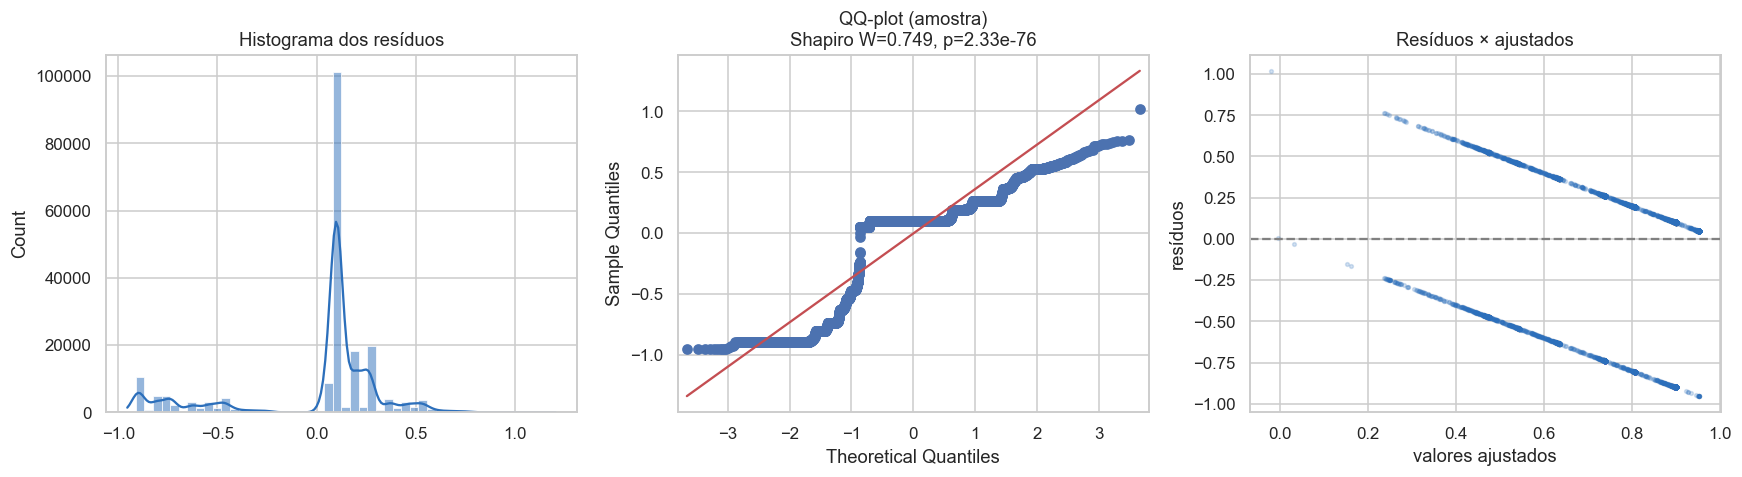

Shapiro-Wilk (amostra n=8000): W=0.7491, p=2.33e-76
Breusch-Pagan: LM=16387.66, p=0  |  F=2223.41, p=0
Durbin-Watson: 1.9957  (≈2 indica ausência de autocorrelação)


In [15]:
m6 = models["M6"]
resid = m6.resid
fitted = m6.fittedvalues

# --- Normalidade ---
idx = RNG.choice(len(resid), size=min(SAMPLE_N, len(resid)), replace=False)
res_s = resid.iloc[idx]
sh_stat, sh_p = stats.shapiro(res_s)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(resid, bins=50, kde=True, ax=axes[0], color="#2c6fbb")
axes[0].set_title("Histograma dos resíduos")
sm.qqplot(res_s, line="s", ax=axes[1])
axes[1].set_title(f"QQ-plot (amostra)\nShapiro W={sh_stat:.3f}, p={sh_p:.3g}")
axes[2].scatter(fitted.iloc[idx], res_s, s=6, alpha=0.2, color="#2c6fbb")
axes[2].axhline(0, color="gray", ls="--")
axes[2].set_xlabel("valores ajustados"); axes[2].set_ylabel("resíduos")
axes[2].set_title("Resíduos × ajustados")
plt.tight_layout(); plt.show()

# --- Homocedasticidade (Breusch-Pagan) ---
bp = het_breuschpagan(resid, m6.model.exog)
# --- Independência (Durbin-Watson) ---
dw = durbin_watson(resid)

print(f"Shapiro-Wilk (amostra n={len(res_s)}): W={sh_stat:.4f}, p={sh_p:.3g}")
print(f"Breusch-Pagan: LM={bp[0]:.2f}, p={bp[1]:.3g}  |  F={bp[2]:.2f}, p={bp[3]:.3g}")
print(f"Durbin-Watson: {dw:.4f}  (≈2 indica ausência de autocorrelação)")

## Passo 13 — Avaliação estatística (comparação dos modelos)

,formula,R2,R2_adj,AIC,BIC,n
modelo,,,,,,
M1,correct ~ mean_confidence,0.0532,0.0532,191895.6113,191916.1034,208155
M2,correct ~ conf_llama + conf_qwen + conf_deepseek,0.0533,0.0533,191880.9583,191921.9424,208155
M3,correct ~ mean_confidence + C(consensus_type),0.1117,0.1117,178625.3801,178656.1182,208155
M4,correct ~ mean_confidence * C(consensus_type),0.1222,0.1222,176134.5477,176175.5318,208155
M5,correct ~ mean_confidence + C(consensus_type) ...,0.1387,0.1387,172205.5987,172267.0749,208155
M6,correct ~ conf_llama + conf_qwen + conf_deepse...,0.1390,0.1390,172130.7402,172222.9546,208155


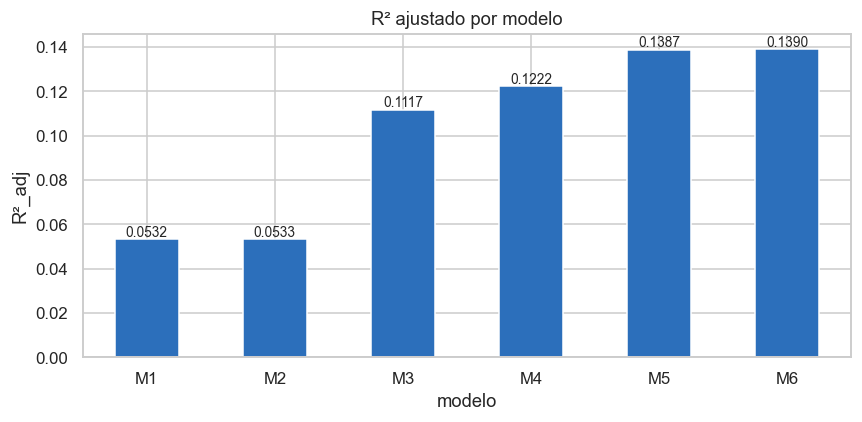

In [16]:
comp = pd.DataFrame([
    {"modelo": name, "formula": FORMULAS[name],
     "R2": res.rsquared, "R2_adj": res.rsquared_adj,
     "AIC": res.aic, "BIC": res.bic, "n": int(res.nobs)}
    for name, res in models.items()
]).set_index("modelo")
display(comp)

fig, ax = plt.subplots(figsize=(8, 4))
comp["R2_adj"].plot(kind="bar", ax=ax, color="#2c6fbb")
for i, v in enumerate(comp["R2_adj"]):
    ax.annotate(f"{v:.4f}", (i, v), ha="center", va="bottom", fontsize=9)
ax.set_title("R² ajustado por modelo"); ax.set_ylabel("R²_adj")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Hipóteses de pesquisa — leitura dos resultados

- **H1** (maior confiança ⇒ maior acerto): sinal/significância de `mean_confidence`
  em M1/M3.
- **H2** (unanimidade mais confiável): coeficiente de `C(consensus_type)[T.3x0]`.
- **H3** (relação confiança×qualidade depende do consenso): interação em M4.
- **H4** (domínio influencia): termos `C(dataset)` em M5/M6 e ganho de R².
- **H5** (confianças têm poder explicativo distinto): coeficientes de
  `conf_llama/qwen/deepseek` em M2/M6.
- **H6** (menor dispersão ⇒ maior qualidade): sinal de `std_confidence` em M6
  (espera-se **negativo**).

In [17]:
print("Coeficientes-chave (M6, EP robusto HC1):")
key = ["conf_llama", "conf_qwen", "conf_deepseek", "std_confidence",
       "C(consensus_type)[T.3x0]"]
ct = coef_table(models["M6"])
display(ct.loc[[k for k in key if k in ct.index]])

print("\nGanho de R²_adj ao adicionar fatores:")
print(f"  M1 (só confiança média)      : {models['M1'].rsquared_adj:.4f}")
print(f"  M3 (+ consenso)              : {models['M3'].rsquared_adj:.4f}")
print(f"  M5 (+ domínio)              : {models['M5'].rsquared_adj:.4f}")
print(f"  M6 (completo)               : {models['M6'].rsquared_adj:.4f}")

Coeficientes-chave (M6, EP robusto HC1):


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
conf_llama,0.8812,0.1125,7.8296,0.0000,0.6606,1.1017
conf_qwen,0.7246,0.1988,3.6455,0.0003,0.3350,1.1142
conf_deepseek,0.6079,0.0958,6.3439,0.0000,0.4201,0.7957
std_confidence,1.3569,0.2412,5.6263,0.0000,0.8842,1.8297
C(consensus_type)[T.3x0],0.2637,0.0034,77.2218,0.0000,0.2570,0.2703



Ganho de R²_adj ao adicionar fatores:
  M1 (só confiança média)      : 0.0532
  M3 (+ consenso)              : 0.1117
  M5 (+ domínio)              : 0.1387
  M6 (completo)               : 0.1390


## Exportar análises (.json) — `data/results/mq/regressao`

In [18]:
EXPORT_DIR = ROOT / "data" / "results" / "mq" / "regressao"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def _jsonable(o):
    if isinstance(o, pd.DataFrame):
        return o.reset_index().to_dict(orient="records")
    if isinstance(o, pd.Series):
        return o.to_dict()
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, dict):
        return {k: _jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_jsonable(v) for v in o]
    return o


payload = {
    "descricao": "Regressão linear (LPM, EP HC1) — confiança x acerto da anotação",
    "datasets_e_pastas": used,
    "n_total": int(len(df_reg)),
    "distribuicao_resposta": df_reg["correct"].value_counts().to_dict(),
    "modelos": {
        name: {
            "formula": FORMULAS[name],
            "R2": float(res.rsquared),
            "R2_adj": float(res.rsquared_adj),
            "aic": float(res.aic), "bic": float(res.bic), "n": int(res.nobs),
            "coeficientes": _jsonable(coef_table(res)),
        }
        for name, res in models.items()
    },
    "diagnosticos_M6": {
        "shapiro_W": float(sh_stat), "shapiro_p": float(sh_p),
        "breusch_pagan_LM": float(bp[0]), "breusch_pagan_p": float(bp[1]),
        "durbin_watson": float(dw),
    },
}

with open(EXPORT_DIR / "analise_regressao.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

df_reg.drop(columns=[c for c in df_reg.columns if c.startswith("z_")]).to_csv(
    EXPORT_DIR / "base_regressao.csv", index=False)

print("✓ Salvo em:", EXPORT_DIR)
for p in sorted(EXPORT_DIR.glob("*")):
    print("  -", p.name)

✓ Salvo em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\mq\regressao
  - analise_regressao.json
  - base_regressao.csv
